# Data Collection

In [62]:
import pandas as pd
import numpy as np

##########################################
'''DATA'''
##########################################
alpha = 0.3 #TODO Trouver une source qui justifie ce choix 
Tmax= 15 #au dessus : pas de chauffage
Tmin = 0 #en dessous: chauffage maximal
cos_phi = 0.95
delta_Umin = 0.9 #TODO changer avec la bonne valeur selon le type de cable
delta_Umax = 1.10 #TODO changer avec la bonne valeur selon le type de cable
V = 20 #kV

##########################################
# 1. Charger data du fichier 87_grid
file = "87_0_grid.xlsx"

parameters = pd.read_excel(file, sheet_name="parameters")
f =  parameters["f_hz"].values[0] 
omega = 2 * np.pi * f

base = pd.read_excel(file, sheet_name="res_ext_grid") #TODO : CHANGER AVEC NOUVEAU OPF POUR SCENARIO 2 
P_base = base["p_mw"].values
Q_base = base["q_mvar"].values

load = pd.read_excel(file, sheet_name="load")
P_load_agg = - load.groupby("bus")["p_mw"].sum() #tableau avec pour chaque node une valeur de load associée 
Q_load_agg = - load.groupby("bus")["q_mvar"].sum()

bus = pd.read_excel(file, sheet_name="bus")
n_nodes = len(bus)
nodes = range(n_nodes)
P_load = {k: P_load_agg.get(k, 0) for k in nodes}
Q_load = {k: Q_load_agg.get(k, 0) for k in nodes}

bus_ref = pd.read_excel(file, sheet_name="res_bus") #TODO : CHANGER AVEC NOUVEAU OPF POUR SCENARIO 2 
P_ref = - bus_ref["p_mw"].values 
Q_ref = - bus_ref["q_mvar"].values

trafo = pd.read_excel(file, sheet_name="trafo")
pcc_bus = int(trafo["lv_bus"].iloc[0])

lines = pd.read_excel(file, sheet_name="line")
line_data = pd.DataFrame({
    "from_bus": lines["from_bus"],
    "to_bus": lines["to_bus"],
    "length": lines["length_km"],
    "r": lines["r_ohm_per_km"] * lines["length_km"],
    "x": lines["x_ohm_per_km"] * lines["length_km"],
    "c": lines["c_nf_per_km"] * lines["length_km"] * 1e-9,
    "I_max": lines["max_i_ka"]
})

#Construire gij, bij, bij(sh)
line_data["g"] = line_data["r"] / (line_data["r"]**2 + line_data["x"]**2)
line_data["b"] = -line_data["x"] / (line_data["r"]**2 + line_data["x"]**2)
line_data["b_sh"] = omega * line_data["c"]
#print(line_data.head()) 

#Construire les matrices Jacobiennes
# Initialisation des matrices
J_Ptheta = np.zeros((n_nodes, n_nodes))
J_QU     = np.zeros((n_nodes, n_nodes))
J_PU     = np.zeros((n_nodes, n_nodes))
# Boucle sur chaque ligne ij
for l in range(len(line_data)):
    i = int(line_data.loc[l, "from_bus"])
    j = int(line_data.loc[l, "to_bus"])

    gij = line_data.loc[l, "g"]
    bij = line_data.loc[l, "b"]
    bsh = line_data.loc[l, "b_sh"]
# 1. MATRICE J_Ptheta
    # diagonale
    J_Ptheta[i, i] -= bij
    J_Ptheta[j, j] -= bij
    # hors diagonale
    J_Ptheta[i, j] += bij
    J_Ptheta[j, i] += bij
# 2. MATRICE J_QU
    # diagonale
    J_QU[i, i] -= (2*bsh + bij)
    J_QU[j, j] -= (2*bsh + bij)
    # hors diagonale
    J_QU[i, j] += bij
    J_QU[j, i] += bij
# 3. MATRICE J_PU
    # diagonale
    J_PU[i, i] += gij
    J_PU[j, j] += gij
    # hors diagonale
    J_PU[i, j] -= gij
    J_PU[j, i] -= gij
# 4. MATRICE J_Qtheta
J_Qtheta = - J_PU
#Calculer S_max 
line_data["S_max"] = np.sqrt(3) * line_data["I_max"] * V

##########################################
# 2. Charger data des PV
irr = pd.read_csv("irradiance_hourly.csv") #TODO changer avec le bon fichier 
G = irr["irradiance_W_m2"].values  # taille 8760
G_norm = G / np.max(G)

pv_data = []    #Data PV par load 
pv_data_dt = [] #Data PV par load par heure de l'année 
for k in range(n_nodes):
    Pk = abs(P_load_agg.get(k, 0))  # load au node k
    Ppv = alpha * Pk #Ppv au node k 
    Qpv = Ppv * np.tan(np.arccos(cos_phi))
    pv_data.append({
        "bus": k,
        "P_pv": Ppv,
        "Q_pv": Qpv
    })
    for t in range(len(G)):
        Ppv = alpha * Pk * G_norm[t]
        Qpv = Ppv * np.tan(np.arccos(cos_phi))
        pv_data_dt.append({
            "bus": k,
            "time": t,
            "P_pv": Ppv,
            "Q_pv": Qpv
        })
pv_df = pd.DataFrame(pv_data)
P_pv_max = pv_df.set_index("bus")["P_pv"]
Q_pv_max = pv_df.set_index("bus")["Q_pv"]
pv_df.to_csv("pv_data.csv", index=False)
pv_df_dt = pd.DataFrame(pv_data_dt)
pv_df_dt.to_csv("pv_data_dt.csv", index=False)

##########################################
# 3. Charger data des HP
COP = 3.9         # heat pump (nPro) #TODO changer quand zone bien délimitée
P_hp_total = - 26072 / 1000 # MW thermique (nPro) #TODO changer quand zone bien délimitée
temp = pd.read_csv("temperature_hourly.csv") #TODO changer avec bon fichier

T = temp["temperature_C"].values
f_t = np.clip((Tmax - T) / (Tmax - Tmin), 0, 1) # Fonction chauffage qui indique consommation de l'HP en fonction de la temperature exterieure 

P_hp_total_elec = P_hp_total / COP #puissance electrique totale 
Pk_total = P_load_agg.sum() # Total load

hp_data = []
hp_data_dt = []
for k in range(n_nodes):
    Pk = P_load_agg.get(k, 0)
    P_hp = P_hp_total_elec * (Pk / Pk_total)
    hp_data.append({
        "bus": k,
        "P_hp": P_hp
    })
    for t in range(len(T)):
        P_hp_dt = P_hp * f_t[t]
        hp_data_dt.append({
            "bus": k,
            "time": t,
            "P_hp": P_hp_dt
        })
hp_df = pd.DataFrame(hp_data)
P_hp_max = hp_df.set_index("bus")["P_hp"] #Structure les données pour Gurobi
hp_df.to_csv("hp_data.csv", index=False)
hp_df_dt = pd.DataFrame(hp_data_dt)
hp_df_dt.to_csv("hp_data_dt.csv", index=False)

# print("Bilan de faisabilité par nœud :")
# for k in nodes:
#     # Convention : PV > 0 (génération), HP < 0 (conso), load < 0 (conso)
#     pk_min = 0 + P_hp_max.get(k, 0) + P_load.get(k, 0)          # P_pv = 0, HP au max
#     pk_max = P_pv_max.get(k, 0) + 0 + P_load.get(k, 0)           # P_pv au max, HP = 0
#     pr = P_ref[k]
#     print(f"Nœud {k:3d} | P_ref={pr:+.4f} | Pk ∈ [{pk_min:+.4f}, {pk_max:+.4f}] {'❌' if pr < pk_min or pr > pk_max else '✅'}")


# Probleme d'optimization qui crée le  FFOR

In [56]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# =========================
# MODELE
# =========================

model = gp.Model("FFOR_static")

# =========================
# VARIABLES
# =========================
Pk = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Pk")
Qk = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qk")
theta = model.addVars(n_nodes, lb=-GRB.INFINITY, name="theta")
delta_U     = model.addVars(n_nodes, lb=-GRB.INFINITY, name="U")
P_pv = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Ppv")
Q_pv = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qpv")
P_hp = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Php")

# =========================
# CONTRAINTES FFOR
# =========================

# # Nodal Power Balance
# for k in nodes:
#     model.addConstr(
#         Pk[k] == P_pv[k] + P_hp[k] + P_load.get(k, 0),
#         name=f"Nodal_P_balance_{k}"
#     )
#     model.addConstr(
#         Qk[k] == Q_pv[k] + Q_load.get(k, 0),
#         name=f"Nodal_Q_balance_{k}"
#     )
# Nodal Power Balance — sauf le nœud PCC
for k in nodes:
    if k == pcc_bus:
        continue  # ← le PCC est libre, pas de bilan nodal
    model.addConstr(
        Pk[k] == P_pv[k] + P_hp[k] + P_load.get(k, 0),
        name=f"Nodal_P_balance_{k}"
    )
    model.addConstr(
        Qk[k] == Q_pv[k] + Q_load.get(k, 0),
        name=f"Nodal_Q_balance_{k}"
    )
#Linearized Power Flow
for k in nodes:
    model.addConstr(
        Pk[k] == P_ref[k]
        +
        gp.quicksum(J_Ptheta[k, j] * theta[j] for j in nodes)
        +
        gp.quicksum(J_PU[k, j] * delta_U[j] for j in nodes),
        name=f"Power_flow_P{k}"
    )
    model.addConstr(
        Qk[k] == Q_ref[k]
        +
        gp.quicksum(J_Qtheta[k, j] * theta[j] for j in nodes)
        +
        gp.quicksum(J_QU[k, j] * delta_U[j] for j in nodes),
        name=f"Power_flow_Q{k}"
    )

#PV constraint 
for k in nodes:
    model.addConstr(P_pv[k] <= P_pv_max.get(k, 0),
        name=f"PV_Pmax_pos_{k}"
    )
    model.addConstr(0 <= P_pv[k],
        name=f"PV_Pmax_neg_{k}"
    )
    model.addConstr(Q_pv[k] <= Q_pv_max[k],
        name=f"PV_Qmax_pos_{k}"
    )
    model.addConstr(Q_pv[k] >= -Q_pv_max[k],
        name=f"PV_Qmax_neg_{k}"
    )

#HP constraint 
for k in nodes:
    model.addConstr(P_hp[k] >= P_hp_max.get(k, 0),
        name=f"HP_Pmax_pos_{k}"
    )
    model.addConstr(0 >= P_hp[k],
        name=f"HP_Pmax_neg_{k}"
    )

#Line flow constraint
for idx, row in line_data.iterrows():
    i = int(row["from_bus"])
    j = int(row["to_bus"])
    b = row["b"]
    Smax = row["S_max"]
    Pij = b * (theta[i] - theta[j]) #TODO verifier cette equation
    Qij = b * (delta_U[i] - delta_U[j]) #TODO verifier cette equation

    model.addQConstr(
        Pij * Pij + Qij * Qij <= Smax * Smax,
        name=f"line_flow_{i}_{j}"
    )

#Voltage Constraint
for k in nodes:
    model.addConstr(
        V + delta_U[k] >= delta_Umin*V,
        name=f"Umin_{k}"
    )
    model.addConstr(
        V + delta_U[k] <= delta_Umax*V,
        name=f"Umax_{k}"
    )

#Slack Constraint
model.addConstr(
    theta[pcc_bus] == 0,
    name="Slack_theta"
)
model.addConstr(
    delta_U[pcc_bus] == 0,
    name="Slack_voltage"
)

# =========================
# OBJECTIF
# =========================
a = 0.5
b = 0.5

model.setObjective(
    a * (Pk[pcc_bus] - float(P_base[0]))
    + b * (Qk[pcc_bus] - float(Q_base[0])),
    GRB.MINIMIZE
)

# =========================
# SOLVE
# =========================
model.Params.DualReductions = 0  # désactive les réductions duales
model.optimize()
if model.status == GRB.INFEASIBLE:
    print("Calcul IIS...")
    model.computeIIS()
    model.write("model.ilp")
    
    print("\n--- Contraintes infaisables ---")
    for c in model.getConstrs():
        if c.IISConstr:
            print(f"  {c.ConstrName}")
    
    print("\n--- Bornes infaisables ---")
    for v in model.getVars():
        if v.IISLB:
            print(f"  {v.VarName} lb={v.lb} trop haute")
        if v.IISUB:
            print(f"  {v.VarName} ub={v.ub} trop basse")

# =========================
# AFFICHAGE RESULTATS
# =========================

if model.status == GRB.OPTIMAL:
    print("\n✅ OPTIMAL SOLUTION FOUND\n")

    print("----- PCC -----")
    print(f"P_pcc = {Pk[pcc_bus].X:.4f}")
    print(f"Q_pcc = {Qk[pcc_bus].X:.4f}")

    print("\n----- Pk -----")
    for k in nodes:
        print(f"Pk[{k}] = {Pk[k].X:.4f}")

    print("\n----- Qk -----")
    for k in nodes:
        print(f"Qk[{k}] = {Qk[k].X:.4f}")

    print("\n----- Theta -----")
    for k in nodes:
        print(f"theta[{k}] = {theta[k].X:.6f}")

    print("\n----- Voltage (delta_U) -----")
    for k in nodes:
        print(f"delta_U[{k}] = {delta_U[k].X:.6f}")

    print("\n----- PV -----")
    for k in nodes:
        print(f"P_pv[{k}] = {P_pv[k].X:.4f}, Q_pv[{k}] = {Q_pv[k].X:.4f}")

    print("\n----- HP -----")
    for k in nodes:
        print(f"P_hp[{k}] = {P_hp[k].X:.4f}")

else:
    print("\n❌ Optimization did not find optimal solution")
    print("Status code:", model.status)

# model.computeIIS()

# print("\n--- Contraintes infaisables ---")
# for c in model.getConstrs():
#     if c.IISConstr:
#         print(f"  {c.ConstrName}  RHS={c.RHS:.4f}")

# for v in model.getVars():
#     if v.IISLB:
#         print(f"  VAR {v.VarName} lb={v.lb} trop haute")
#     if v.IISUB:
#         print(f"  VAR {v.VarName} ub={v.ub} trop basse")


Set parameter DualReductions to value 0
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-1065G7 CPU @ 1.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
DualReductions  0

Optimize a model with 924 rows, 539 columns and 2056 nonzeros (Min)
Model fingerprint: 0x929ad685
Model has 2 linear objective coefficients and an objective constant of -6.3470047460994108e+00
Model has 75 quadratic constraints
Coefficient statistics:
  Matrix range     [4e-01, 1e+03]
  QMatrix range    [2e-01, 1e+06]
  Objective range  [5e-01, 5e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-03, 9e+00]
  QRHS range       [5e+01, 5e+02]

Presolve removed 774 rows and 264 columns
Presolve time: 0.02s
Presolved: 296 rows, 496 columns, 1445 nonzeros
Presolved model has 75 second-order cone constraints
Ordering time: 0.00s

Barrier statistics:


# FFOR

  1/72 | phi=0.0° | P=6.278, Q=3.797
  2/72 | phi=5.0° | P=6.278, Q=2.882
  3/72 | phi=10.0° | P=6.278, Q=2.882
  4/72 | phi=15.0° | P=6.278, Q=2.882
  5/72 | phi=20.0° | P=6.278, Q=2.882
  6/72 | phi=25.0° | P=6.278, Q=2.882
  7/72 | phi=30.0° | P=6.278, Q=2.882
  8/72 | phi=35.0° | P=6.278, Q=2.882
  9/72 | phi=40.0° | P=6.278, Q=2.882
  10/72 | phi=45.0° | P=6.278, Q=2.882
  11/72 | phi=50.0° | P=6.278, Q=2.882
  12/72 | phi=55.0° | P=6.278, Q=2.882
  13/72 | phi=60.0° | P=6.278, Q=2.882
  14/72 | phi=65.0° | P=6.278, Q=2.882
  15/72 | phi=70.0° | P=6.278, Q=2.882
  16/72 | phi=75.0° | P=6.278, Q=2.882
  17/72 | phi=80.0° | P=6.278, Q=2.882
  18/72 | phi=85.0° | P=6.278, Q=2.882
  19/72 | phi=90.0° | P=6.326, Q=2.882
  20/72 | phi=95.0° | P=8.933, Q=2.887
  21/72 | phi=100.0° | P=8.933, Q=2.887
  22/72 | phi=105.0° | P=8.933, Q=2.887
  23/72 | phi=110.0° | P=8.933, Q=2.887
  24/72 | phi=115.0° | P=8.933, Q=2.887
  25/72 | phi=120.0° | P=8.933, Q=2.887
  26/72 | phi=125.0° | P=8.933,

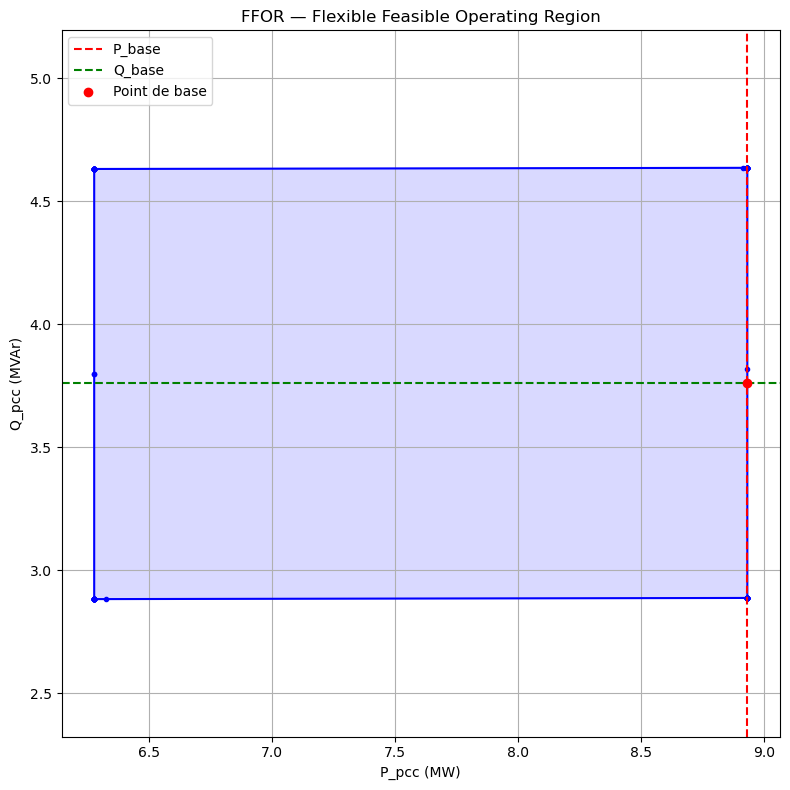

S_max min = 7.27 MVA
S_max max = 22.34 MVA
Plage P_pcc : [6.28, 8.93] MW
Plage Q_pcc : [2.88, 4.64] MVAr


In [64]:
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

def solve_ffor(a, b):
    """Résout le modèle FFOR pour une direction (a, b) donnée."""
    model = gp.Model("FFOR_static")
    model.Params.OutputFlag = 0  # silence Gurobi

    # --- Variables ---
    Pk      = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Pk")
    Qk      = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qk")
    theta   = model.addVars(n_nodes, lb=-GRB.INFINITY, name="theta")
    delta_U = model.addVars(n_nodes, lb=-GRB.INFINITY, name="U")
    P_pv    = model.addVars(n_nodes, lb=0,             name="Ppv")
    Q_pv    = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qpv")
    P_hp    = model.addVars(n_nodes, ub=0,             name="Php")

    # --- Contraintes ---
    for k in nodes:
        if k == pcc_bus:
            continue
        model.addConstr(Pk[k] == P_pv[k] + P_hp[k] + P_load.get(k, 0))
        model.addConstr(Qk[k] == Q_pv[k] + Q_load.get(k, 0))

    for k in nodes:
        model.addConstr(Pk[k] == P_ref[k] + gp.quicksum(J_Ptheta[k,j]*theta[j] + J_PU[k,j]*delta_U[j] for j in nodes))
        model.addConstr(Qk[k] == Q_ref[k] + gp.quicksum(J_Qtheta[k,j]*theta[j] + J_QU[k,j]*delta_U[j] for j in nodes))

    for k in nodes:
        model.addConstr(P_pv[k] <= P_pv_max.get(k, 0))
        model.addConstr(Q_pv[k] <=  Q_pv_max.get(k, 0))
        model.addConstr(Q_pv[k] >= -Q_pv_max.get(k, 0))
        model.addConstr(P_hp[k] >= P_hp_max.get(k, 0))

    for idx, row in line_data.iterrows():
        i, j = int(row["from_bus"]), int(row["to_bus"])
        Pij = row["b"] * (theta[i] - theta[j])
        Qij = row["b"] * (delta_U[i] - delta_U[j])
        model.addQConstr(Pij*Pij + Qij*Qij <= row["S_max"]**2)

    for k in nodes:
        model.addConstr(V + delta_U[k] >= delta_Umin * V)
        model.addConstr(V + delta_U[k] <= delta_Umax * V)

    model.addConstr(theta[pcc_bus] == 0)
    model.addConstr(delta_U[pcc_bus] == 0)

    for k in nodes:
        S_inv = P_pv_max.get(k, 0) / cos_phi  # capacité apparente de l'onduleur
        model.addQConstr(
            P_pv[k] * P_pv[k] + Q_pv[k] * Q_pv[k] <= S_inv * S_inv,
            name=f"PV_Smax_{k}"
        )

    # --- Objectif directionnel ---
    model.setObjective(
        a * Pk[pcc_bus] + b * Qk[pcc_bus],
        GRB.MINIMIZE
    )

    model.optimize()

    if model.status == GRB.OPTIMAL:
        return Pk[pcc_bus].X, Qk[pcc_bus].X
    else:
        return None, None


# --- Balayage sur 360° ---
n_angles = 72  # résolution : tous les 5°
angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)

P_points = []
Q_points = []

for i, phi in enumerate(angles):
    a = np.cos(phi)
    b = np.sin(phi)
    p, q = solve_ffor(a, b)
    if p is not None:
        P_points.append(p)
        Q_points.append(q)
    print(f"  {i+1}/{n_angles} | phi={np.degrees(phi):.1f}° | P={p:.3f}, Q={q:.3f}" if p else f"  {i+1}/{n_angles} | ❌ infaisable")

# Fermer le polygone
P_points.append(P_points[0])
Q_points.append(Q_points[0])

# --- Plot ---
plt.figure(figsize=(8, 8))
plt.plot(P_points, Q_points, 'b-o', markersize=3, linewidth=1.5)
plt.fill(P_points, Q_points, alpha=0.15, color='blue')
plt.axvline(float(P_base[0]), color='r', linestyle='--', label='P_base')
plt.axhline(float(Q_base[0]), color='g', linestyle='--', label='Q_base')
plt.scatter([float(P_base[0])], [float(Q_base[0])], color='red', zorder=5, label='Point de base')
plt.xlabel("P_pcc (MW)")
plt.ylabel("Q_pcc (MVAr)")
plt.title("FFOR — Flexible Feasible Operating Region")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.savefig("FFOR.png", dpi=150)
plt.show()

print(f"S_max min = {line_data['S_max'].min():.2f} MVA")
print(f"S_max max = {line_data['S_max'].max():.2f} MVA")
print(f"Plage P_pcc : [{min(P_points):.2f}, {max(P_points):.2f}] MW")
print(f"Plage Q_pcc : [{min(Q_points):.2f}, {max(Q_points):.2f}] MVAr")